# double_wg_supermode.ipynb

Double 220 nm Si waveguide supermode analysis in Lumerical MODE/FDE.

Goal:
1. Build two identical 500 nm × 220 nm Si strip waveguides in SiO2.
2. Sweep the edge-to-edge gap from 100 nm to 750 nm in 15 points.
3. For each gap, solve the even and odd TE-like supermodes.
4. Extract `neff_even`, `neff_odd`, `delta_neff`, `delta_beta`, `kappa`, and `L_50_50`.
5. Plot 50/50 coupling length versus gap.

For identical phase-matched waveguides:

$$
\Delta\beta = |\beta_\mathrm{even}-\beta_\mathrm{odd}|,
\qquad
\kappa = \frac{\Delta\beta}{2},
\qquad
P_\mathrm{cross}(L)=\sin^2\left(\frac{\Delta\beta L}{2}\right).
$$

Therefore:

$$
L_{50/50}
=
\frac{\pi}{2\Delta\beta}
=
\frac{\lambda_0}{4|n_\mathrm{even}-n_\mathrm{odd}|}.
$$

## Cell 1 — Imports and Lumerical API

In [1]:
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Change this to your Lumerical installation path
# ------------------------------------------------------------------
LUMERICAL_PYTHON_API = r"C:\Program Files\Lumerical\v261\api\python"

if not os.path.isdir(LUMERICAL_PYTHON_API):
    raise FileNotFoundError(
        f"Lumerical Python API folder not found:\n{LUMERICAL_PYTHON_API}"
    )

if LUMERICAL_PYTHON_API not in sys.path:
    sys.path.append(LUMERICAL_PYTHON_API)

import lumapi

print("lumapi imported successfully")

lumapi imported successfully


## Cell 2 — Settings

In [2]:
settings = {
    # ------------------------------------------------------------------
    # Built-in Lumerical Palik materials
    # ------------------------------------------------------------------
    "si_material_name": "Si (Silicon) - Palik",
    "sio2_material_name": "SiO2 (Glass) - Palik",

    # Material fit range, like Material Explorer / MODE MCM fit
    "material_fit_min_nm": 1200.0,
    "material_fit_max_nm": 1700.0,

    # Design wavelength range for material checking
    "lambda_min_nm": 1500.0,
    "lambda_max_nm": 1600.0,
    "lambda_points": 501,

    # Main simulation wavelength
    "wavelength_um": 1.55,

    # ------------------------------------------------------------------
    # Double waveguide geometry
    # Propagation direction = z
    # Cross section = x-y
    # Gap = edge-to-edge gap between the two Si waveguides
    # ------------------------------------------------------------------
    "wg_width_um": 0.300,
    "wg_thickness_um": 0.220,
    "wg_center_y_um": 0.0,

    # Gap sweep: 100 nm to 750 nm, 15 points
    "gap_start_um": 0.100,
    "gap_stop_um": 0.750,
    "gap_num_points": 15,

    # SiO2 surrounding box
    "oxide_x_span_um": 50.0,
    "oxide_y_span_um": 50.0,
    "z_span_um": 10.0,

    # FDE region
    "fde_x_span_um": 15.0,
    "fde_y_span_um": 15.0,
    "fde_center_x_um": 0.0,
    "fde_center_y_um": 0.0,

    # Options: "PML" or "Metal"
    "fde_bc": "PML",

    # FDE mesh
    "fde_dx_um": 0.05,
    "fde_dy_um": 0.05,
    "number_of_trial_modes": 2,

    # Optional extra mesh around both waveguides
    "use_extra_mesh": True,
    "extra_mesh_name": "mesh_double_wg",
    "mesh_x_margin_um": 0.40,
    "mesh_y_span_um": 1.50,
    "local_dx_um": 0.01,
    "local_dy_um": 0.01,

    # TE-like mode filtering
    "te_fraction_min": 0.5,

    # Guided-mode filter
    "guided_neff_tolerance": 1e-4,

    # Session
    "hide_lumerical": False,

    # Saving
    "folder_name": "double_wg_supermode",
    "simulation_file_name": "double_si_wg_gap_sweep",
}

um = 1e-6
c0 = 299792458.0

gaps_um = np.linspace(
    settings["gap_start_um"],
    settings["gap_stop_um"],
    settings["gap_num_points"],
)

settings["gap_values_um"] = gaps_um.tolist()

settings

{'si_material_name': 'Si (Silicon) - Palik',
 'sio2_material_name': 'SiO2 (Glass) - Palik',
 'material_fit_min_nm': 1200.0,
 'material_fit_max_nm': 1700.0,
 'lambda_min_nm': 1500.0,
 'lambda_max_nm': 1600.0,
 'lambda_points': 501,
 'wavelength_um': 1.55,
 'wg_width_um': 0.3,
 'wg_thickness_um': 0.22,
 'wg_center_y_um': 0.0,
 'gap_start_um': 0.1,
 'gap_stop_um': 0.75,
 'gap_num_points': 15,
 'oxide_x_span_um': 50.0,
 'oxide_y_span_um': 50.0,
 'z_span_um': 10.0,
 'fde_x_span_um': 15.0,
 'fde_y_span_um': 15.0,
 'fde_center_x_um': 0.0,
 'fde_center_y_um': 0.0,
 'fde_bc': 'PML',
 'fde_dx_um': 0.05,
 'fde_dy_um': 0.05,
 'number_of_trial_modes': 2,
 'use_extra_mesh': True,
 'extra_mesh_name': 'mesh_double_wg',
 'mesh_x_margin_um': 0.4,
 'mesh_y_span_um': 1.5,
 'local_dx_um': 0.01,
 'local_dy_um': 0.01,
 'te_fraction_min': 0.5,
 'guided_neff_tolerance': 0.0001,
 'hide_lumerical': False,
 'folder_name': 'double_wg_supermode',
 'simulation_file_name': 'double_si_wg_gap_sweep',
 'gap_values_um': 

## Cell 3 — Validate settings and start MODE

In [3]:
def check_boundary_condition_name(bc):
    allowed = ["PML", "Metal"]
    if bc not in allowed:
        raise ValueError(f"Invalid fde_bc = {bc}. Use one of {allowed}.")


check_boundary_condition_name(settings["fde_bc"])

if abs(settings["wg_thickness_um"] - 0.220) > 1e-12:
    raise ValueError("This notebook is intended for 220 nm Si thickness.")

if settings["gap_start_um"] <= 0 or settings["gap_stop_um"] <= 0:
    raise ValueError("Gap values must be positive.")

if not (
    settings["material_fit_min_nm"]
    <= settings["lambda_min_nm"]
    < settings["lambda_max_nm"]
    <= settings["material_fit_max_nm"]
):
    raise ValueError("The design wavelength range must be inside the material fit range.")

max_total_width_um = 2 * settings["wg_width_um"] + settings["gap_stop_um"]

if settings["fde_x_span_um"] <= max_total_width_um + 2.0:
    raise ValueError("FDE x span is too small. Increase fde_x_span_um.")

print("Settings are valid.")
print(f"Material fit range: {settings['material_fit_min_nm']}–{settings['material_fit_max_nm']} nm")
print(f"Design range: {settings['lambda_min_nm']}–{settings['lambda_max_nm']} nm")
print(f"Waveguide: {settings['wg_width_um']*1000:.0f} nm wide × {settings['wg_thickness_um']*1000:.0f} nm thick")
print(f"Gap sweep: {gaps_um[0]*1000:.1f} to {gaps_um[-1]*1000:.1f} nm, N = {len(gaps_um)}")
print(f"FDE boundary condition: {settings['fde_bc']}")

mode = lumapi.MODE(hide=settings["hide_lumerical"])
mode.newproject()

print("MODE session started.")

Settings are valid.
Material fit range: 1200.0–1700.0 nm
Design range: 1500.0–1600.0 nm
Waveguide: 300 nm wide × 220 nm thick
Gap sweep: 100.0 to 750.0 nm, N = 15
FDE boundary condition: PML
MODE session started.


## Cell 4 — Check Palik materials

In [4]:
mode.switchtolayout()

for mat in [settings["si_material_name"], settings["sio2_material_name"]]:
    try:
        mode.eval(f'test_material_data = getmaterial("{mat}", "sampled data");')
        raw = np.array(mode.getv("test_material_data"))
        print(f"Material found: {mat}")
        print("sampled data shape:", raw.shape)
    except Exception as e:
        raise RuntimeError(
            f"Could not read material sampled data for:\n{mat}\n\n"
            "Check the exact material name in the Lumerical material database."
        ) from e

Material found: Si (Silicon) - Palik
sampled data shape: (512, 2)
Material found: SiO2 (Glass) - Palik
sampled data shape: (419, 2)


## Cell 5 — Material fit over 1200–1700 nm

In [5]:
material_dir = Path.cwd() / "material_data"
material_dir.mkdir(exist_ok=True)

materials = {
    "Si": settings["si_material_name"],
    "SiO2": settings["sio2_material_name"],
}

lambda_fit_nm = np.linspace(
    settings["material_fit_min_nm"],
    settings["material_fit_max_nm"],
    1001,
)
lambda_fit_m = lambda_fit_nm * 1e-9
f_fit_Hz = c0 / lambda_fit_m

lambda_design_nm = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    settings["lambda_points"],
)
lambda_design_m = lambda_design_nm * 1e-9
f_design_Hz = c0 / lambda_design_m

fit_f_min_Hz = c0 / (settings["material_fit_max_nm"] * 1e-9)
fit_f_max_Hz = c0 / (settings["material_fit_min_nm"] * 1e-9)

material_data = {}

for label, mat_name in materials.items():

    print(f"\nProcessing material: {label} | {mat_name}")

    mode.putv("f_fit_Hz", f_fit_Hz)
    mode.putv("f_design_Hz", f_design_Hz)
    mode.putv("fit_f_min_Hz", fit_f_min_Hz)
    mode.putv("fit_f_max_Hz", fit_f_max_Hz)

    mode.eval(f"""
    n_raw_fit = getindex("{mat_name}", f_fit_Hz);
    n_raw_design = getindex("{mat_name}", f_design_Hz);

    n_mode_fit = getmodeindex(
        "{mat_name}",
        f_fit_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );

    n_mode_design = getmodeindex(
        "{mat_name}",
        f_design_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );
    """)

    n_raw_fit_complex = np.squeeze(np.array(mode.getv("n_raw_fit"), dtype=complex))
    n_raw_design_complex = np.squeeze(np.array(mode.getv("n_raw_design"), dtype=complex))
    n_mode_fit_complex = np.squeeze(np.array(mode.getv("n_mode_fit"), dtype=complex))
    n_mode_design_complex = np.squeeze(np.array(mode.getv("n_mode_design"), dtype=complex))

    n_raw_fit = np.real(n_raw_fit_complex)
    k_raw_fit = np.abs(np.imag(n_raw_fit_complex))
    n_raw_design = np.real(n_raw_design_complex)
    k_raw_design = np.abs(np.imag(n_raw_design_complex))

    n_mode_fit = np.real(n_mode_fit_complex)
    k_mode_fit = np.abs(np.imag(n_mode_fit_complex))
    n_mode_design = np.real(n_mode_design_complex)
    k_mode_design = np.abs(np.imag(n_mode_design_complex))

    dn_dlambda = np.gradient(n_mode_design) / np.gradient(lambda_design_m)
    ng_mode_design = n_mode_design - lambda_design_m * dn_dlambda

    material_data[label] = {
        "material_name": mat_name,
        "lambda_fit_nm": lambda_fit_nm,
        "n_raw_fit": n_raw_fit,
        "k_raw_fit": k_raw_fit,
        "n_mode_fit": n_mode_fit,
        "k_mode_fit": k_mode_fit,
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "n_raw": n_raw_design,
        "k_raw": k_raw_design,
        "n": n_mode_design,
        "k": k_mode_design,
        "ng": ng_mode_design,
    }

    df_fit = pd.DataFrame({
        "lambda_nm": lambda_fit_nm,
        "n_raw_getindex": n_raw_fit,
        "k_raw_getindex": k_raw_fit,
        "n_MODE_fit_getmodeindex": n_mode_fit,
        "k_MODE_fit_getmodeindex": k_mode_fit,
    })

    df_design = pd.DataFrame({
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,
        "n_raw_getindex": n_raw_design,
        "k_raw_getindex": k_raw_design,
        "n_MODE_fit": n_mode_design,
        "k_MODE_fit": k_mode_design,
        "ng_MODE_fit": ng_mode_design,
    })

    fit_csv_path = material_dir / f"{label}_Palik_MODE_fit_1200_1700nm.csv"
    design_csv_path = material_dir / f"{label}_Palik_MODE_fit_eval_1500_1600nm.csv"

    df_fit.to_csv(fit_csv_path, index=False)
    df_design.to_csv(design_csv_path, index=False)

    print("Saved:", fit_csv_path)
    print("Saved:", design_csv_path)

print("\nDone. Material data are stored in material_data.")


Processing material: Si | Si (Silicon) - Palik
Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_Palik_MODE_fit_1200_1700nm.csv
Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_Palik_MODE_fit_eval_1500_1600nm.csv

Processing material: SiO2 | SiO2 (Glass) - Palik
Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_Palik_MODE_fit_1200_1700nm.csv
Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_Palik_MODE_fit_eval_1500_1600nm.csv

Done. Material data are stored in material_data.


## Cell 6 — Plot material fit

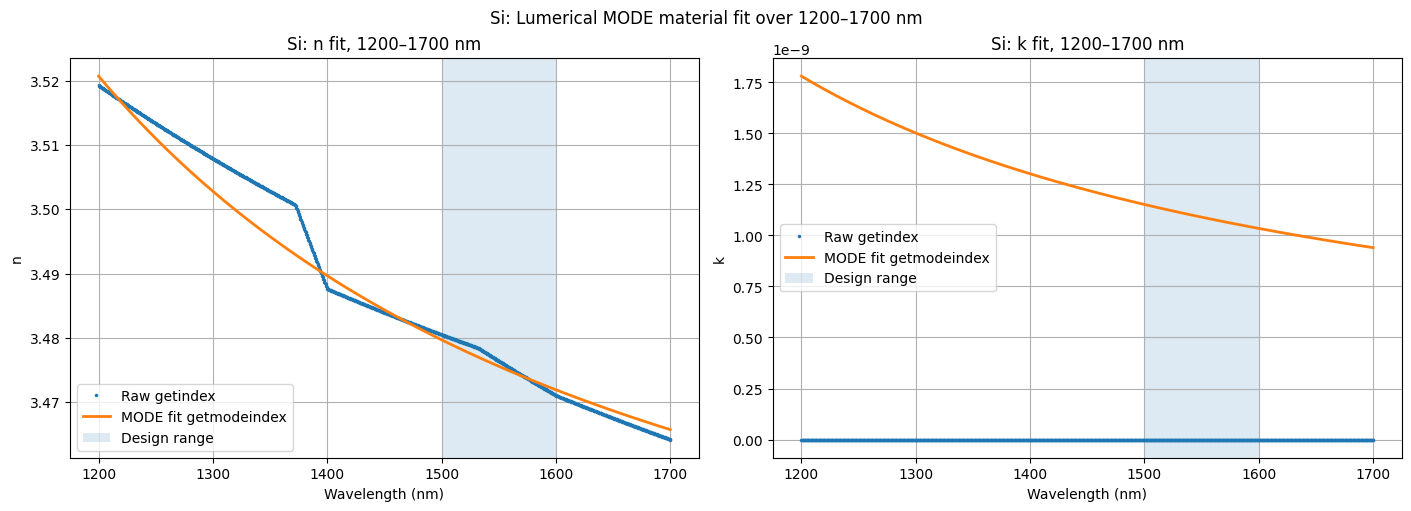

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\Si_MODE_fit_1200_1700nm.png


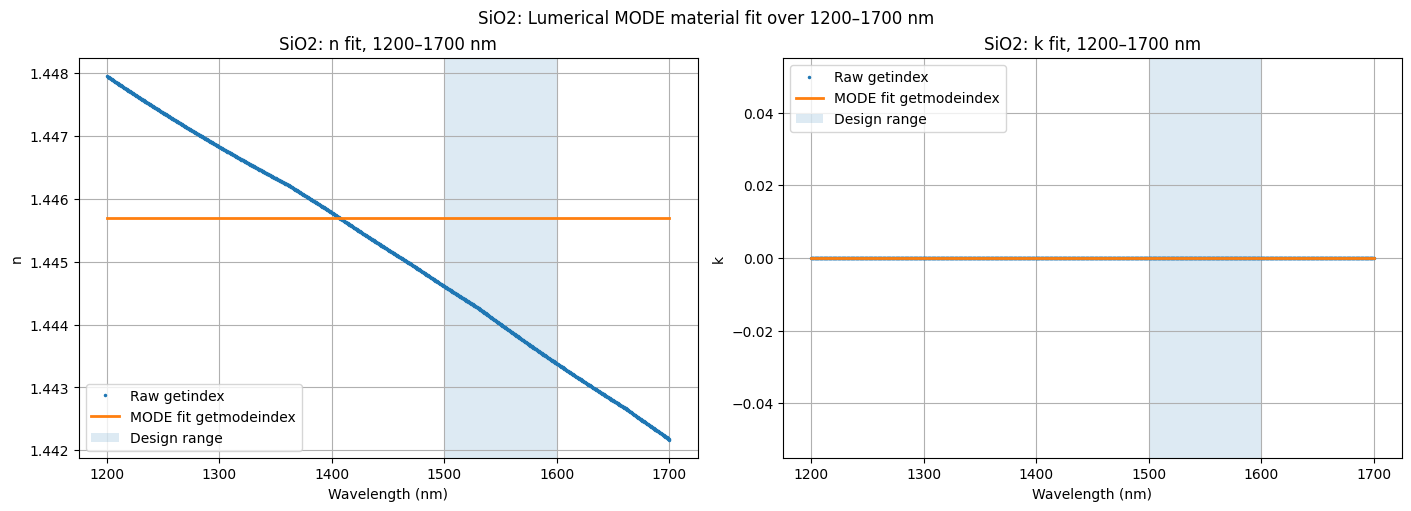

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\material_data\SiO2_MODE_fit_1200_1700nm.png


In [6]:
for label, d in material_data.items():

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axs[0].plot(d["lambda_fit_nm"], d["n_raw_fit"], ".", markersize=3, label="Raw getindex")
    axs[0].plot(d["lambda_fit_nm"], d["n_mode_fit"], "-", linewidth=2, label="MODE fit getmodeindex")
    axs[0].axvspan(settings["lambda_min_nm"], settings["lambda_max_nm"], alpha=0.15, label="Design range")
    axs[0].set_title(f"{label}: n fit, 1200–1700 nm")
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("n")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(d["lambda_fit_nm"], d["k_raw_fit"], ".", markersize=3, label="Raw getindex")
    axs[1].plot(d["lambda_fit_nm"], d["k_mode_fit"], "-", linewidth=2, label="MODE fit getmodeindex")
    axs[1].axvspan(settings["lambda_min_nm"], settings["lambda_max_nm"], alpha=0.15, label="Design range")
    axs[1].set_title(f"{label}: k fit, 1200–1700 nm")
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("k")
    axs[1].grid(True)
    axs[1].legend()

    fig.suptitle(f"{label}: Lumerical MODE material fit over 1200–1700 nm")

    plot_path = material_dir / f"{label}_MODE_fit_1200_1700nm.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Cell 7 — Material values at 1550 nm

In [7]:
lambda0_nm = settings["wavelength_um"] * 1000.0

material_at_lambda0 = {}

for label, d in material_data.items():
    material_at_lambda0[label] = {
        "n": float(np.interp(lambda0_nm, d["lambda_nm"], d["n"])),
        "k": float(np.interp(lambda0_nm, d["lambda_nm"], d["k"])),
        "ng": float(np.interp(lambda0_nm, d["lambda_nm"], d["ng"])),
    }

print(f"Material values at lambda = {lambda0_nm:.1f} nm")
print("Values are from MODE multi-coefficient fit over 1200–1700 nm.\n")

for label, d in material_at_lambda0.items():
    print(
        f"{label}: "
        f"n = {d['n']:.8f}, "
        f"k = {d['k']:.3e}, "
        f"ng_material = {d['ng']:.8f}"
    )

Material values at lambda = 1550.0 nm
Values are from MODE multi-coefficient fit over 1200–1700 nm.

Si: n = 3.47554455, k = 1.090e-09, ng_material = 3.59578939
SiO2: n = 1.44569554, k = 0.000e+00, ng_material = 1.44569554


## Cell 8 — Function cell: build double waveguide, extract supermodes

In [8]:
def squeeze_arr(a):
    return np.squeeze(np.array(a))


def scalar_or_nan(x):
    try:
        x = np.squeeze(np.array(x))
        if x.size == 0:
            return np.nan
        return np.real(x.item())
    except Exception:
        return np.nan


def get_from_mode_or_list(mode_obj, mode_number, key, default=np.nan):
    try:
        return mode_obj.getdata(f"FDE::data::mode{mode_number}", key)
    except Exception:
        pass

    try:
        return mode_obj.getdata("FDE::data", key)[mode_number - 1]
    except Exception:
        return default


def get_te_fraction(mode_obj, mode_number):
    keys = [
        "waveguide TE fraction",
        "TE polarization fraction",
        "waveguide TE/TM fraction",
    ]

    for key in keys:
        value = get_from_mode_or_list(mode_obj, mode_number, key, default=np.nan)
        value = scalar_or_nan(value)
        if np.isfinite(value):
            return value

    return np.nan


def get_mode_neff(mode_obj, mode_number):
    neff = get_from_mode_or_list(mode_obj, mode_number, "neff", default=np.nan)
    if np.all(pd.isna(neff)):
        return np.nan + 1j * np.nan
    return complex(np.squeeze(neff))


def get_mode_ng(mode_obj, mode_number):
    ng = get_from_mode_or_list(mode_obj, mode_number, "ng", default=np.nan)
    if np.all(pd.isna(ng)):
        return np.nan + 1j * np.nan
    return complex(np.squeeze(ng))


def is_guided_mode(neff_real, n_clad, tolerance):
    return neff_real > n_clad + tolerance


def waveguide_centers_from_gap(settings_local, gap_um):
    half_sep_um = 0.5 * (settings_local["wg_width_um"] + gap_um)
    return -half_sep_um, +half_sep_um


def build_double_wg_fde_model(mode_obj, settings_local, gap_um, lms_file_path=None):
    """
    Build one complete FDE model for a given gap.

    Full cross-section is used, because this avoids relying on symmetry BC names
    and makes the even/odd classification more robust.
    """

    um_local = 1e-6
    gap_um = float(gap_um)

    left_x_um, right_x_um = waveguide_centers_from_gap(settings_local, gap_um)
    total_width_um = 2.0 * settings_local["wg_width_um"] + gap_um

    mode_obj.switchtolayout()
    mode_obj.deleteall()

    # ------------------------------
    # SiO2 box
    # ------------------------------
    mode_obj.addrect()
    mode_obj.set("name", "SiO2_box")
    mode_obj.set("material", settings_local["sio2_material_name"])
    mode_obj.set("x", 0.0)
    mode_obj.set("y", 0.0)
    mode_obj.set("z", 0.0)
    mode_obj.set("x span", settings_local["oxide_x_span_um"] * um_local)
    mode_obj.set("y span", settings_local["oxide_y_span_um"] * um_local)
    mode_obj.set("z span", settings_local["z_span_um"] * um_local)

    # ------------------------------
    # Left Si waveguide
    # ------------------------------
    mode_obj.addrect()
    mode_obj.set("name", "Si_wg_left")
    mode_obj.set("material", settings_local["si_material_name"])
    mode_obj.set("x", left_x_um * um_local)
    mode_obj.set("y", settings_local["wg_center_y_um"] * um_local)
    mode_obj.set("z", 0.0)
    mode_obj.set("x span", settings_local["wg_width_um"] * um_local)
    mode_obj.set("y span", settings_local["wg_thickness_um"] * um_local)
    mode_obj.set("z span", settings_local["z_span_um"] * um_local)

    # ------------------------------
    # Right Si waveguide
    # ------------------------------
    mode_obj.addrect()
    mode_obj.set("name", "Si_wg_right")
    mode_obj.set("material", settings_local["si_material_name"])
    mode_obj.set("x", right_x_um * um_local)
    mode_obj.set("y", settings_local["wg_center_y_um"] * um_local)
    mode_obj.set("z", 0.0)
    mode_obj.set("x span", settings_local["wg_width_um"] * um_local)
    mode_obj.set("y span", settings_local["wg_thickness_um"] * um_local)
    mode_obj.set("z span", settings_local["z_span_um"] * um_local)

    # ------------------------------
    # FDE solver
    # ------------------------------
    mode_obj.addfde()
    mode_obj.set("solver type", "2D Z normal")
    mode_obj.set("x", settings_local["fde_center_x_um"] * um_local)
    mode_obj.set("y", settings_local["fde_center_y_um"] * um_local)
    mode_obj.set("x span", settings_local["fde_x_span_um"] * um_local)
    mode_obj.set("y span", settings_local["fde_y_span_um"] * um_local)
    mode_obj.set("wavelength", settings_local["wavelength_um"] * um_local)

    bc = settings_local["fde_bc"]
    mode_obj.set("x min bc", bc)
    mode_obj.set("x max bc", bc)
    mode_obj.set("y min bc", bc)
    mode_obj.set("y max bc", bc)

    mode_obj.set("number of trial modes", settings_local["number_of_trial_modes"])
    mode_obj.set("define x mesh by", "maximum mesh step")
    mode_obj.set("define y mesh by", "maximum mesh step")
    mode_obj.set("dx", settings_local["fde_dx_um"] * um_local)
    mode_obj.set("dy", settings_local["fde_dy_um"] * um_local)

    # ------------------------------
    # Optional extra mesh around both waveguides and the gap
    # ------------------------------
    if settings_local["use_extra_mesh"]:
        mode_obj.addmesh()
        mode_obj.set("name", settings_local["extra_mesh_name"])
        mode_obj.set("x", 0.0)
        mode_obj.set("y", settings_local["wg_center_y_um"] * um_local)
        mode_obj.set("z", 0.0)
        mode_obj.set("x span", (total_width_um + 2.0 * settings_local["mesh_x_margin_um"]) * um_local)
        mode_obj.set("y span", settings_local["mesh_y_span_um"] * um_local)
        mode_obj.set("z span", settings_local["z_span_um"] * um_local)
        mode_obj.set("override x mesh", 1)
        mode_obj.set("override y mesh", 1)
        mode_obj.set("dx", settings_local["local_dx_um"] * um_local)
        mode_obj.set("dy", settings_local["local_dy_um"] * um_local)

    if lms_file_path is not None:
        mode_obj.save(str(lms_file_path))


def extract_double_wg_modes(mode_obj, settings_local, material_at_lambda0_local, gap_um):
    """
    Extract compact data for all solved modes.
    """

    rows = []
    num_modes = int(settings_local["number_of_trial_modes"])
    n_clad = material_at_lambda0_local["SiO2"]["n"]

    for m in range(1, num_modes + 1):
        neff_complex = get_mode_neff(mode_obj, m)
        if not np.isfinite(np.real(neff_complex)):
            continue

        ng_complex = get_mode_ng(mode_obj, m)
        TE_fraction = get_te_fraction(mode_obj, m)

        neff_real = float(np.real(neff_complex))
        neff_imag = float(np.imag(neff_complex))
        ng_real = float(np.real(ng_complex)) if np.isfinite(np.real(ng_complex)) else np.nan

        rows.append({
            "gap_um": float(gap_um),
            "gap_nm": float(gap_um) * 1000.0,
            "width_um": float(settings_local["wg_width_um"]),
            "thickness_um": float(settings_local["wg_thickness_um"]),
            "wavelength_um": float(settings_local["wavelength_um"]),
            "mode_number": int(m),
            "neff": neff_complex,
            "neff_real": neff_real,
            "neff_imag": neff_imag,
            "ng": ng_complex,
            "ng_real": ng_real,
            "TE_fraction": float(TE_fraction) if np.isfinite(TE_fraction) else np.nan,
            "is_guided": bool(is_guided_mode(
                neff_real=neff_real,
                n_clad=n_clad,
                tolerance=settings_local["guided_neff_tolerance"],
            )),
        })

    return pd.DataFrame(rows)


def classify_even_odd_from_neff(df_modes, settings_local):
    """
    For identical waveguides, the two TE-like supermodes closest to the
    single-waveguide fundamental form the even/odd pair.

    Usually the even supermode has the larger neff and the odd supermode has
    the smaller neff for the fundamental TE pair.
    """

    if len(df_modes) == 0:
        raise RuntimeError("No modes were extracted.")

    d = df_modes.copy()

    if "is_guided" in d.columns:
        d = d[d["is_guided"]].copy()

    if "TE_fraction" in d.columns:
        d = d[d["TE_fraction"] >= settings_local["te_fraction_min"]].copy()

    d = d[np.isfinite(d["neff_real"])].copy()
    d = d.sort_values("neff_real", ascending=False).reset_index(drop=True)

    if len(d) < 2:
        raise RuntimeError(
            "Could not find two guided TE-like supermodes. "
            "Increase number_of_trial_modes or relax te_fraction_min."
        )

    even = d.iloc[0].copy()
    odd = d.iloc[1].copy()

    even["supermode"] = "even"
    odd["supermode"] = "odd"

    return pd.DataFrame([even, odd]).reset_index(drop=True)


def derive_coupling_from_supermodes(df_pair, settings_local):
    """
    Calculate coupling metrics from the even/odd neff split.
    """

    wavelength_um = float(settings_local["wavelength_um"])
    wavelength_m = wavelength_um * 1e-6

    neff_even = float(df_pair[df_pair["supermode"] == "even"]["neff_real"].iloc[0])
    neff_odd = float(df_pair[df_pair["supermode"] == "odd"]["neff_real"].iloc[0])

    delta_neff = abs(neff_even - neff_odd)
    delta_beta_per_m = 2.0 * np.pi * delta_neff / wavelength_m
    kappa_per_m = 0.5 * delta_beta_per_m

    if delta_neff <= 0 or not np.isfinite(delta_neff):
        L_50_50_um = np.nan
        L_full_transfer_um = np.nan
        beat_length_period_um = np.nan
    else:
        # P_cross = sin^2(delta_beta L / 2)
        L_50_50_um = wavelength_um / (4.0 * delta_neff)
        L_full_transfer_um = wavelength_um / (2.0 * delta_neff)
        beat_length_period_um = wavelength_um / delta_neff

    return {
        "gap_um": float(df_pair["gap_um"].iloc[0]),
        "gap_nm": float(df_pair["gap_nm"].iloc[0]),
        "wavelength_um": wavelength_um,
        "neff_even": neff_even,
        "neff_odd": neff_odd,
        "delta_neff": delta_neff,
        "delta_beta_per_m": delta_beta_per_m,
        "delta_beta_per_um": delta_beta_per_m * 1e-6,
        "kappa_per_m": kappa_per_m,
        "kappa_per_um": kappa_per_m * 1e-6,
        "L_50_50_um": L_50_50_um,
        "L_full_transfer_um": L_full_transfer_um,
        "beat_length_period_um": beat_length_period_um,
        "even_mode_number": int(df_pair[df_pair["supermode"] == "even"]["mode_number"].iloc[0]),
        "odd_mode_number": int(df_pair[df_pair["supermode"] == "odd"]["mode_number"].iloc[0]),
        "TE_fraction_even": float(df_pair[df_pair["supermode"] == "even"]["TE_fraction"].iloc[0]),
        "TE_fraction_odd": float(df_pair[df_pair["supermode"] == "odd"]["TE_fraction"].iloc[0]),
    }


def double_wg_supermode_sequential(gap_um, save_lms=False, lms_file_path=None):
    """
    Sequential version using the already-open global `mode` session.
    Good for debugging and safest for one license.
    """

    build_double_wg_fde_model(
        mode_obj=mode,
        settings_local=settings,
        gap_um=float(gap_um),
        lms_file_path=lms_file_path if save_lms else None,
    )

    mode.findmodes()

    df_modes = extract_double_wg_modes(
        mode_obj=mode,
        settings_local=settings,
        material_at_lambda0_local=material_at_lambda0,
        gap_um=float(gap_um),
    )

    df_pair = classify_even_odd_from_neff(df_modes, settings)
    coupling_row = derive_coupling_from_supermodes(df_pair, settings)

    return df_modes, df_pair, pd.DataFrame([coupling_row])


def double_wg_supermode_worker(args):
    """
    Parallel worker.

    Each worker:
    - opens a new MODE session
    - builds one gap geometry
    - solves modes
    - extracts compact mode table
    - derives the even/odd coupling result
    - closes the MODE session
    """

    (
        gap_um,
        settings_local,
        material_at_lambda0_local,
        lumerical_python_api,
        worker_run_dir,
    ) = args

    import os
    import sys
    from pathlib import Path
    import numpy as np
    import pandas as pd

    if lumerical_python_api not in sys.path:
        sys.path.append(lumerical_python_api)

    import lumapi

    gap_um = float(gap_um)
    worker_run_dir = Path(worker_run_dir)
    worker_run_dir.mkdir(exist_ok=True, parents=True)

    gap_tag = f"{gap_um:.4f}".replace(".", "p")
    lms_path = worker_run_dir / f"double_wg_gap_{gap_tag}um.lms"

    mode_local = None

    try:
        mode_local = lumapi.MODE(hide=settings_local["hide_lumerical"])
        mode_local.newproject()

        build_double_wg_fde_model(
            mode_obj=mode_local,
            settings_local=settings_local,
            gap_um=gap_um,
            lms_file_path=lms_path,
        )

        mode_local.findmodes()

        df_modes = extract_double_wg_modes(
            mode_obj=mode_local,
            settings_local=settings_local,
            material_at_lambda0_local=material_at_lambda0_local,
            gap_um=gap_um,
        )

        df_pair = classify_even_odd_from_neff(df_modes, settings_local)
        df_coupling = pd.DataFrame([
            derive_coupling_from_supermodes(df_pair, settings_local)
        ])

        df_modes["status"] = "success"
        df_modes["error"] = ""
        df_modes["worker_lms_file"] = str(lms_path)

        df_pair["status"] = "success"
        df_pair["error"] = ""
        df_pair["worker_lms_file"] = str(lms_path)

        df_coupling["status"] = "success"
        df_coupling["error"] = ""
        df_coupling["worker_lms_file"] = str(lms_path)

    except Exception as e:
        err = str(e)

        df_modes = pd.DataFrame([{
            "gap_um": gap_um,
            "gap_nm": gap_um * 1000.0,
            "status": "failed",
            "error": err,
        }])

        df_pair = pd.DataFrame([{
            "gap_um": gap_um,
            "gap_nm": gap_um * 1000.0,
            "status": "failed",
            "error": err,
        }])

        df_coupling = pd.DataFrame([{
            "gap_um": gap_um,
            "gap_nm": gap_um * 1000.0,
            "status": "failed",
            "error": err,
        }])

    finally:
        try:
            if mode_local is not None:
                mode_local.close()
        except Exception:
            pass

    return df_modes, df_pair, df_coupling


print("Function cell loaded.")
print("Available functions:")
print("  double_wg_supermode_sequential(gap_um)")
print("  double_wg_supermode_worker(args)")

Function cell loaded.
Available functions:
  double_wg_supermode_sequential(gap_um)
  double_wg_supermode_worker(args)


## Cell 9 — Debug one gap sequentially

In [9]:
# Run this before the full sweep to confirm the geometry and mode extraction.
# You can set run_debug_gap = False after it works once.

run_debug_gap = True

debug_gap_um = 0.150

if run_debug_gap:
    df_modes_debug, df_pair_debug, df_coupling_debug = double_wg_supermode_sequential(
        gap_um=debug_gap_um,
        save_lms=True,
        lms_file_path=Path.cwd() / f"debug_double_wg_gap_{debug_gap_um:.4f}um.lms",
    )

    print("All modes:")
    display_cols = ["gap_nm", "mode_number", "is_guided", "neff_real", "ng_real", "TE_fraction"]
    print(df_modes_debug[display_cols].to_string(index=False))

    print("\nSelected even/odd pair:")
    pair_cols = ["gap_nm", "supermode", "mode_number", "neff_real", "TE_fraction"]
    print(df_pair_debug[pair_cols].to_string(index=False))

    print("\nCoupling result:")
    result_cols = ["gap_nm", "neff_even", "neff_odd", "delta_neff", "kappa_per_um", "L_50_50_um", "L_full_transfer_um"]
    print(df_coupling_debug[result_cols].to_string(index=False))

All modes:
 gap_nm  mode_number  is_guided  neff_real  ng_real  TE_fraction
  150.0            1       True   1.961664 3.697720     0.956088
  150.0            2       True   1.715403 4.517472     0.919342

Selected even/odd pair:
 gap_nm supermode  mode_number  neff_real  TE_fraction
  150.0      even            1   1.961664     0.956088
  150.0       odd            2   1.715403     0.919342

Coupling result:
 gap_nm  neff_even  neff_odd  delta_neff  kappa_per_um  L_50_50_um  L_full_transfer_um
  150.0   1.961664  1.715403    0.246261      0.499129    1.573536            3.147073


## Cell 10 — Gap sweep: parallel or sequential

In [10]:
# ------------------------------------------------------------
# Sweep control
# ------------------------------------------------------------
use_parallel = True

# Usually start with 2.
# Increase only if you have enough RAM and enough Lumerical license capacity.
max_workers = 2

# ------------------------------------------------------------
# Create run folders
# ------------------------------------------------------------
project_root = Path.cwd()
simulation_runs_dir = project_root / "simulation_runs"
simulation_runs_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = simulation_runs_dir / f"{settings['folder_name']}_{timestamp}"
run_dir.mkdir(exist_ok=False)

csv_dir = run_dir / "csv"
plot_dir = run_dir / "plots"
lms_dir = run_dir / "lms_files"

csv_dir.mkdir(exist_ok=True)
plot_dir.mkdir(exist_ok=True)
lms_dir.mkdir(exist_ok=True)

pd.DataFrame([{"key": k, "value": v} for k, v in settings.items()]).to_csv(
    run_dir / "settings.csv",
    index=False,
)

pd.DataFrame({"gap_um": gaps_um, "gap_nm": gaps_um * 1000.0}).to_csv(
    run_dir / "gaps.csv",
    index=False,
)

print("Run directory:")
print(run_dir)
print(f"use_parallel = {use_parallel}")
print(f"max_workers = {max_workers}")
print(f"Number of gap points = {len(gaps_um)}")

all_mode_dfs = []
all_pair_dfs = []
all_coupling_dfs = []

# ------------------------------------------------------------
# Sequential sweep
# ------------------------------------------------------------
if not use_parallel:

    for i, gap_um in enumerate(gaps_um, start=1):
        print("=" * 80)
        print(f"[{i}/{len(gaps_um)}] gap = {gap_um * 1000:.1f} nm")

        try:
            lms_file_path = lms_dir / f"double_wg_gap_{gap_um:.4f}um.lms"

            df_modes, df_pair, df_coupling = double_wg_supermode_sequential(
                gap_um=float(gap_um),
                save_lms=True,
                lms_file_path=lms_file_path,
            )

            for d in [df_modes, df_pair, df_coupling]:
                d["status"] = "success"
                d["error"] = ""
                d["worker_lms_file"] = str(lms_file_path)

        except Exception as e:
            err = str(e)
            df_modes = pd.DataFrame([{"gap_um": gap_um, "gap_nm": gap_um * 1000, "status": "failed", "error": err}])
            df_pair = df_modes.copy()
            df_coupling = df_modes.copy()

        gap_tag = f"{gap_um:.4f}".replace(".", "p")
        df_modes.to_csv(csv_dir / f"gap_{gap_tag}um_all_modes.csv", index=False)
        df_pair.to_csv(csv_dir / f"gap_{gap_tag}um_even_odd_pair.csv", index=False)
        df_coupling.to_csv(csv_dir / f"gap_{gap_tag}um_coupling.csv", index=False)

        all_mode_dfs.append(df_modes)
        all_pair_dfs.append(df_pair)
        all_coupling_dfs.append(df_coupling)

        print(df_coupling.to_string(index=False))

# ------------------------------------------------------------
# Parallel sweep
# ------------------------------------------------------------
else:

    try:
        from joblib import Parallel, delayed
    except ImportError as e:
        raise ImportError(
            "joblib is needed for parallel sweep. Install with:\n"
            "pip install joblib\n\n"
            "Or set use_parallel = False."
        ) from e

    worker_args = []

    for gap_um in gaps_um:
        worker_args.append((
            float(gap_um),
            settings,
            material_at_lambda0,
            LUMERICAL_PYTHON_API,
            str(lms_dir),
        ))

    print("Launching parallel MODE workers...")
    print("Each worker opens its own MODE session.")

    results = Parallel(
        n_jobs=max_workers,
        backend="loky",
        verbose=10,
    )(
        delayed(double_wg_supermode_worker)(args)
        for args in worker_args
    )

    for df_modes, df_pair, df_coupling in results:
        gap_um = float(df_coupling["gap_um"].iloc[0])
        gap_tag = f"{gap_um:.4f}".replace(".", "p")

        df_modes.to_csv(csv_dir / f"gap_{gap_tag}um_all_modes.csv", index=False)
        df_pair.to_csv(csv_dir / f"gap_{gap_tag}um_even_odd_pair.csv", index=False)
        df_coupling.to_csv(csv_dir / f"gap_{gap_tag}um_coupling.csv", index=False)

        all_mode_dfs.append(df_modes)
        all_pair_dfs.append(df_pair)
        all_coupling_dfs.append(df_coupling)

# ------------------------------------------------------------
# Combine and save all results
# ------------------------------------------------------------
if len(all_coupling_dfs) == 0:
    raise RuntimeError("No gap points were simulated.")

df_all_modes = pd.concat(all_mode_dfs, ignore_index=True)
df_even_odd = pd.concat(all_pair_dfs, ignore_index=True)
df_coupling = pd.concat(all_coupling_dfs, ignore_index=True)

df_all_modes = df_all_modes.sort_values(
    by=["gap_um", "mode_number"] if "mode_number" in df_all_modes.columns else ["gap_um"],
).reset_index(drop=True)

df_even_odd = df_even_odd.sort_values(
    by=["gap_um", "supermode"] if "supermode" in df_even_odd.columns else ["gap_um"],
).reset_index(drop=True)

df_coupling = df_coupling.sort_values("gap_um").reset_index(drop=True)

df_all_modes.to_csv(run_dir / "all_gaps_all_modes.csv", index=False)
df_even_odd.to_csv(run_dir / "all_gaps_even_odd_pairs.csv", index=False)
df_coupling.to_csv(run_dir / "all_gaps_coupling_lengths.csv", index=False)

print("=" * 80)
print("Sweep finished.")
print("Saved:")
print(run_dir / "all_gaps_all_modes.csv")
print(run_dir / "all_gaps_even_odd_pairs.csv")
print(run_dir / "all_gaps_coupling_lengths.csv")

df_coupling

Run directory:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352
use_parallel = True
max_workers = 2
Number of gap points = 15
Launching parallel MODE workers...
Each worker opens its own MODE session.


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   30.2s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  1.0min
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:  2.5min


Sweep finished.
Saved:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\all_gaps_all_modes.csv
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\all_gaps_even_odd_pairs.csv
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\all_gaps_coupling_lengths.csv


[Parallel(n_jobs=2)]: Done  15 out of  15 | elapsed:  4.0min finished


,gap_um,gap_nm,status,error,wavelength_um,neff_even,neff_odd,delta_neff,delta_beta_per_m,delta_beta_per_um,kappa_per_m,kappa_per_um,L_50_50_um,L_full_transfer_um,beat_length_period_um,even_mode_number,odd_mode_number,TE_fraction_even,TE_fraction_odd,worker_lms_file
0,0.100000,100.000000,failed,Could not find two guided TE-like supermodes. ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.146429,146.428571,success,,1.55,1.963903,1.712911,0.250991,1.017436e+06,1.017436,508717.953613,0.508718,1.543877,3.087755,6.175510,1.0,2.0,0.956393,0.918859,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
2,0.192857,192.857143,success,,1.55,1.926559,1.731083,0.195476,7.923962e+05,0.792396,396198.091899,0.396198,1.982337,3.964674,7.929348,1.0,2.0,0.953987,0.924339,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
3,0.239286,239.285714,success,,1.55,1.902874,1.749726,0.153148,6.208105e+05,0.620810,310405.227803,0.310405,2.530235,5.060470,10.120940,1.0,2.0,0.952169,0.926640,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
4,0.285714,285.714286,success,,1.55,1.884303,1.764494,0.119809,4.856639e+05,0.485664,242831.970796,0.242832,3.234328,6.468655,12.937311,1.0,2.0,0.950886,0.928159,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
5,0.332143,332.142857,success,,1.55,1.870699,1.776872,0.093826,3.803413e+05,0.380341,190170.659859,0.190171,4.129965,8.259930,16.519860,1.0,2.0,0.949783,0.929464,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
6,0.378571,378.571429,success,,1.55,1.861850,1.788256,0.073594,2.983273e+05,0.298327,149163.664466,0.149164,5.265345,10.530690,21.061380,1.0,2.0,0.948637,0.930572,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
7,0.425000,425.000000,success,,1.55,1.853670,1.795903,0.057766,2.341653e+05,0.234165,117082.646889,0.117083,6.708066,13.416133,26.832265,1.0,2.0,0.947782,0.931931,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
8,0.471429,471.428571,success,,1.55,1.847405,1.801985,0.045420,1.841159e+05,0.184116,92057.944957,0.092058,8.531563,17.063126,34.126252,1.0,2.0,0.946986,0.933203,c:\Users\Amirali\Desktop\Beam_Splitter_Project...
9,0.517857,517.857143,success,,1.55,1.843743,1.807999,0.035744,1.448948e+05,0.144895,72447.383118,0.072447,10.840946,21.681892,43.363784,1.0,2.0,0.946094,0.934192,c:\Users\Amirali\Desktop\Beam_Splitter_Project...


## Cell 11 — Clean successful results

In [11]:
df_plot = df_coupling.copy()

if "status" in df_plot.columns:
    df_plot = df_plot[df_plot["status"] == "success"].copy()

required_cols = [
    "gap_nm",
    "delta_neff",
    "delta_beta_per_um",
    "kappa_per_um",
    "L_50_50_um",
    "L_full_transfer_um",
]

for col in required_cols:
    if col not in df_plot.columns:
        raise ValueError(f"Missing required column: {col}")

df_plot = df_plot[np.isfinite(df_plot["L_50_50_um"])].copy()
df_plot = df_plot.sort_values("gap_nm").reset_index(drop=True)

print("Successful coupling rows:", len(df_plot))
print(df_plot[[
    "gap_nm",
    "neff_even",
    "neff_odd",
    "delta_neff",
    "kappa_per_um",
    "L_50_50_um",
    "L_full_transfer_um",
]].to_string(index=False))

Successful coupling rows: 14
    gap_nm  neff_even  neff_odd  delta_neff  kappa_per_um  L_50_50_um  L_full_transfer_um
146.428571   1.963903  1.712911    0.250991      0.508718    1.543877            3.087755
192.857143   1.926559  1.731083    0.195476      0.396198    1.982337            3.964674
239.285714   1.902874  1.749726    0.153148      0.310405    2.530235            5.060470
285.714286   1.884303  1.764494    0.119809      0.242832    3.234328            6.468655
332.142857   1.870699  1.776872    0.093826      0.190171    4.129965            8.259930
378.571429   1.861850  1.788256    0.073594      0.149164    5.265345           10.530690
425.000000   1.853670  1.795903    0.057766      0.117083    6.708066           13.416133
471.428571   1.847405  1.801985    0.045420      0.092058    8.531563           17.063126
517.857143   1.843743  1.807999    0.035744      0.072447   10.840946           21.681892
564.285714   1.839644  1.811449    0.028195      0.057146   13.743794  

## Cell 12 — Plot coupling length versus gap

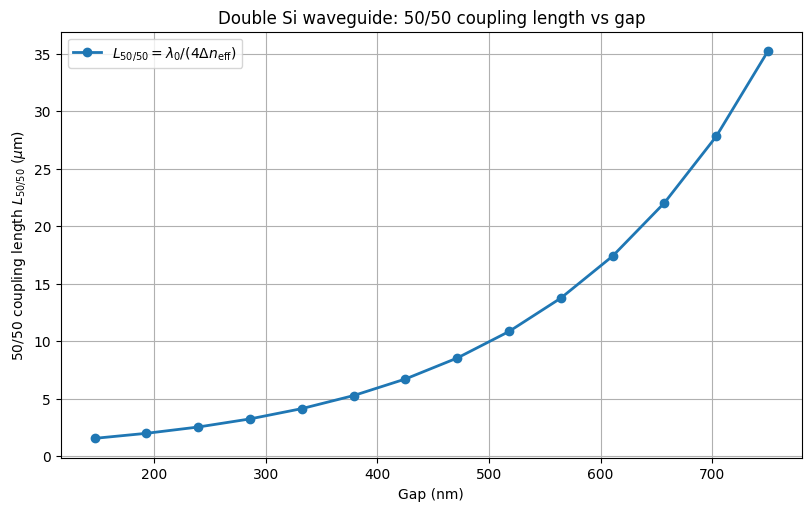

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\plots\L_50_50_vs_gap.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax.plot(
    df_plot["gap_nm"],
    df_plot["L_50_50_um"],
    "o-",
    linewidth=2,
    markersize=6,
    label=r"$L_{50/50}=\lambda_0/(4\Delta n_\mathrm{eff})$",
)

ax.set_xlabel("Gap (nm)")
ax.set_ylabel(r"50/50 coupling length $L_{50/50}$ ($\mu$m)")
ax.set_title("Double Si waveguide: 50/50 coupling length vs gap")
ax.grid(True)
ax.legend()

plot_path = plot_dir / "L_50_50_vs_gap.png"
fig.savefig(plot_path, dpi=300)
plt.show()

print("Saved:", plot_path)

## Cell 13 — Optional: plot coupling coefficient and supermode splitting

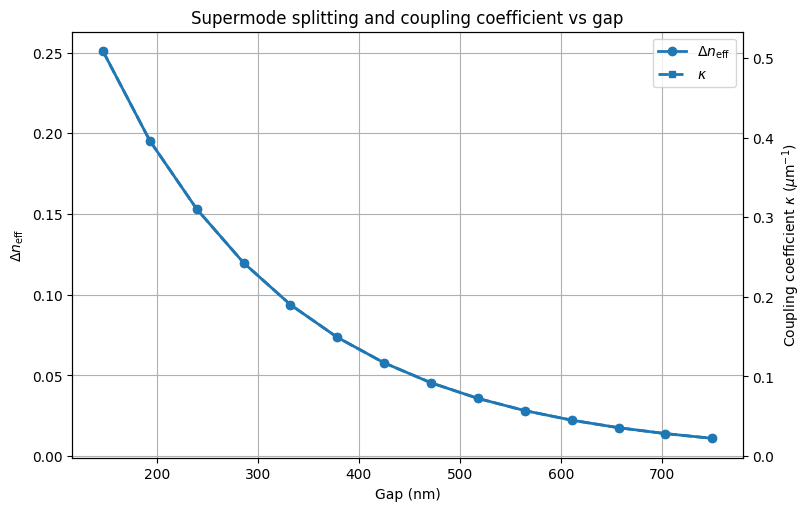

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\plots\delta_neff_and_kappa_vs_gap.png


In [13]:
fig, ax1 = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax1.plot(
    df_plot["gap_nm"],
    df_plot["delta_neff"],
    "o-",
    linewidth=2,
    markersize=6,
    label=r"$\Delta n_\mathrm{eff}$",
)

ax1.set_xlabel("Gap (nm)")
ax1.set_ylabel(r"$\Delta n_\mathrm{eff}$")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["gap_nm"],
    df_plot["kappa_per_um"],
    "s--",
    linewidth=2,
    markersize=5,
    label=r"$\kappa$",
)
ax2.set_ylabel(r"Coupling coefficient $\kappa$ ($\mu$m$^{-1}$)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

ax1.set_title("Supermode splitting and coupling coefficient vs gap")

plot_path = plot_dir / "delta_neff_and_kappa_vs_gap.png"
fig.savefig(plot_path, dpi=300)
plt.show()

print("Saved:", plot_path)

## Highlight gaps where coupling is stronger than width-mismatch detuning

We compare:

$$
\kappa
>
\Delta\beta_\mathrm{mismatch}
=
\frac{2\pi}{\lambda_0}\Delta n_\mathrm{eff,width}
$$

where $\Delta n_\mathrm{eff,width}=0.01583$ comes from the ±5 nm width mismatch estimate.

lambda0 = 1.5500 um
Delta neff from ±5 nm width mismatch = 0.048700
Mismatch beta = 0.197414 1/um
Interpolation method: PCHIP
Maximum interpolated gap satisfying kappa > mismatch_beta:
max_valid_gap = 324.78 nm
kappa at this gap = 0.197644 1/um
Estimated threshold crossing gap = 325.01 nm


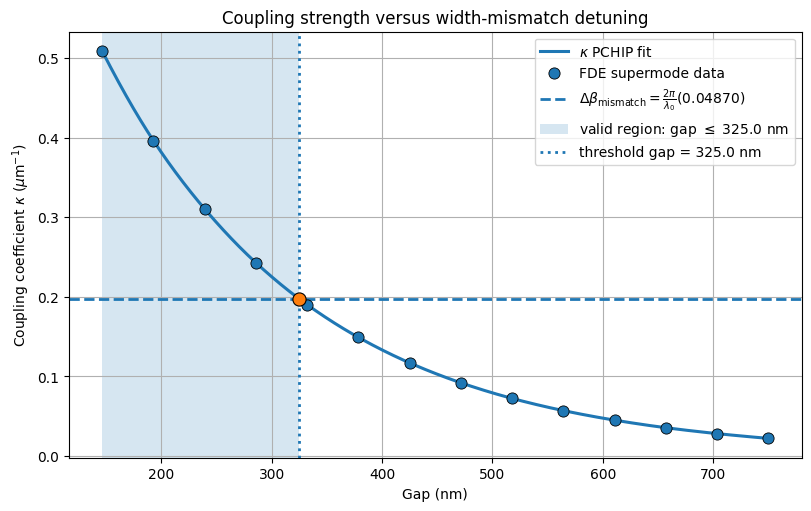

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\plots\kappa_vs_gap_with_width_mismatch_threshold_interpolated.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Mismatch from ±5 nm width tolerance
# ------------------------------------------------------------
delta_neff_width_mismatch = 0.0487

lambda0_um = settings["wavelength_um"]

mismatch_beta_per_um = (
    2.0 * np.pi / lambda0_um
) * delta_neff_width_mismatch

print(f"lambda0 = {lambda0_um:.4f} um")
print(f"Delta neff from ±5 nm width mismatch = {delta_neff_width_mismatch:.6f}")
print(f"Mismatch beta = {mismatch_beta_per_um:.6f} 1/um")

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
df_plot = df_plot.sort_values("gap_nm").reset_index(drop=True)

gap_nm_data = df_plot["gap_nm"].to_numpy(dtype=float)
kappa_data = df_plot["kappa_per_um"].to_numpy(dtype=float)

valid = np.isfinite(gap_nm_data) & np.isfinite(kappa_data)

gap_nm_data = gap_nm_data[valid]
kappa_data = kappa_data[valid]

if len(gap_nm_data) < 3:
    raise RuntimeError("Need at least 3 valid gap points for interpolation.")

# ------------------------------------------------------------
# High-resolution interpolation
# ------------------------------------------------------------
gap_nm_hr = np.linspace(
    np.min(gap_nm_data),
    np.max(gap_nm_data),
    2001,
)

try:
    from scipy.interpolate import PchipInterpolator

    kappa_interp = PchipInterpolator(
        gap_nm_data,
        kappa_data,
        extrapolate=False,
    )

    kappa_hr = kappa_interp(gap_nm_hr)
    interpolation_kind = "PCHIP"

except Exception as e:
    print("Warning: scipy PchipInterpolator not available.")
    print("Using linear interpolation instead.")
    print(e)

    kappa_hr = np.interp(gap_nm_hr, gap_nm_data, kappa_data)
    interpolation_kind = "linear interpolation"

print(f"Interpolation method: {interpolation_kind}")

# ------------------------------------------------------------
# Find high-resolution maximum gap where kappa > mismatch
# ------------------------------------------------------------
strong_hr_mask = kappa_hr > mismatch_beta_per_um

if not np.any(strong_hr_mask):
    max_valid_gap_nm = np.nan
    print("No interpolated gap satisfies kappa > mismatch_beta.")
else:
    max_valid_gap_nm = np.max(gap_nm_hr[strong_hr_mask])
    kappa_at_max_valid = np.interp(max_valid_gap_nm, gap_nm_hr, kappa_hr)

    print("Maximum interpolated gap satisfying kappa > mismatch_beta:")
    print(f"max_valid_gap = {max_valid_gap_nm:.2f} nm")
    print(f"kappa at this gap = {kappa_at_max_valid:.6f} 1/um")

# ------------------------------------------------------------
# Optional: estimate exact crossing by root finding
# ------------------------------------------------------------
crossing_gap_nm = np.nan

if np.nanmin(kappa_hr) <= mismatch_beta_per_um <= np.nanmax(kappa_hr):

    diff_hr = kappa_hr - mismatch_beta_per_um

    sign_change_indices = np.where(np.diff(np.sign(diff_hr)) != 0)[0]

    if len(sign_change_indices) > 0:
        idx = sign_change_indices[0]

        g1 = gap_nm_hr[idx]
        g2 = gap_nm_hr[idx + 1]

        y1 = diff_hr[idx]
        y2 = diff_hr[idx + 1]

        # Linear crossing between the two high-resolution samples
        crossing_gap_nm = g1 - y1 * (g2 - g1) / (y2 - y1)

        print(f"Estimated threshold crossing gap = {crossing_gap_nm:.2f} nm")

# Use crossing gap for annotation if available
if np.isfinite(crossing_gap_nm):
    threshold_gap_nm = crossing_gap_nm
elif np.isfinite(max_valid_gap_nm):
    threshold_gap_nm = max_valid_gap_nm
else:
    threshold_gap_nm = np.nan

# ------------------------------------------------------------
# Plot kappa vs gap with interpolated curve and shaded valid region
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# High-resolution interpolated curve
ax.plot(
    gap_nm_hr,
    kappa_hr,
    "-",
    linewidth=2.2,
    label=rf"$\kappa$ {interpolation_kind} fit",
)

# Original simulation points
ax.scatter(
    gap_nm_data,
    kappa_data,
    s=65,
    edgecolors="black",
    linewidths=0.6,
    zorder=3,
    label="FDE supermode data",
)

# Mismatch threshold line
ax.axhline(
    mismatch_beta_per_um,
    linestyle="--",
    linewidth=2,
    label=(
        r"$\Delta\beta_\mathrm{mismatch}"
        rf"=\frac{{2\pi}}{{\lambda_0}}({delta_neff_width_mismatch:.5f})$"
    ),
)

# Shade acceptable region
if np.isfinite(threshold_gap_nm):
    ax.axvspan(
        np.min(gap_nm_data),
        threshold_gap_nm,
        alpha=0.18,
        label=rf"valid region: gap $\leq$ {threshold_gap_nm:.1f} nm",
    )

    ax.axvline(
        threshold_gap_nm,
        linestyle=":",
        linewidth=2,
        label=rf"threshold gap = {threshold_gap_nm:.1f} nm",
    )

    ax.scatter(
        [threshold_gap_nm],
        [mismatch_beta_per_um],
        s=90,
        edgecolors="black",
        linewidths=0.8,
        zorder=4,
    )

ax.set_xlabel("Gap (nm)")
ax.set_ylabel(r"Coupling coefficient $\kappa$ ($\mu$m$^{-1}$)")
ax.set_title("Coupling strength versus width-mismatch detuning")
ax.grid(True)
ax.legend(loc="best")

plot_path = plot_dir / "kappa_vs_gap_with_width_mismatch_threshold_interpolated.png"
fig.savefig(plot_path, dpi=300)
plt.show()

print("Saved:", plot_path)

## High-resolution interpolation of 50/50 coupling length from 100 nm to 200 nm
This cell creates a smooth interpolation of L_50_50 versus gap and defines
a helper function:

    get_L_50_50_from_gap(gap_nm)

which returns the interpolated 50/50 coupling length.

Interpolation method: PCHIP
Saved high-resolution interpolation table:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\plots\L_50_50_interpolated_100_200nm.csv


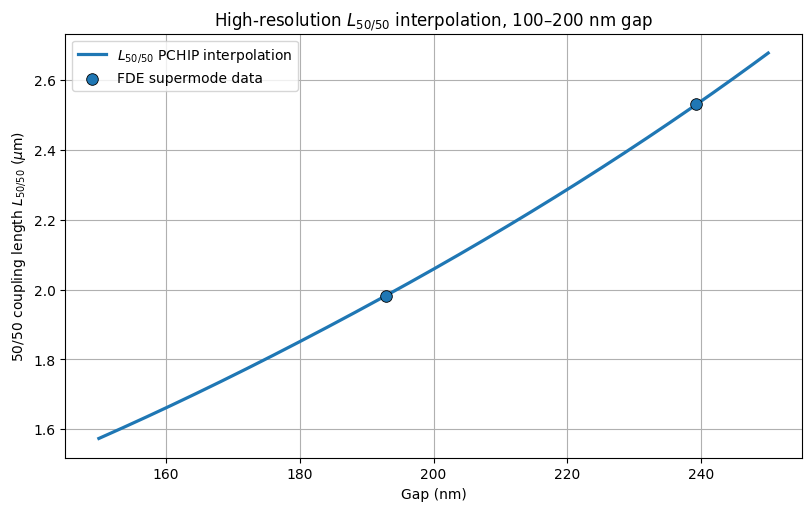

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Double Waveguide SuperMode\simulation_runs\double_wg_supermode_20260616_235352\plots\L_50_50_vs_gap_100_200nm_interpolated.png

Example:
gap = 250.0 nm
L_50_50 = 2.6773 um = 0.002677 mm


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
df_plot = df_plot.sort_values("gap_nm").reset_index(drop=True)

gap_nm_data = df_plot["gap_nm"].to_numpy(dtype=float)
L_50_50_data = df_plot["L_50_50_um"].to_numpy(dtype=float)

valid = np.isfinite(gap_nm_data) & np.isfinite(L_50_50_data)

gap_nm_data = gap_nm_data[valid]
L_50_50_data = L_50_50_data[valid]

if len(gap_nm_data) < 3:
    raise RuntimeError("Need at least 3 valid gap points for interpolation.")

# ------------------------------------------------------------
# Build interpolation function
# ------------------------------------------------------------
try:
    from scipy.interpolate import PchipInterpolator

    L_50_50_interp = PchipInterpolator(
        gap_nm_data,
        L_50_50_data,
        extrapolate=False,
    )

    interpolation_kind = "PCHIP"

except Exception as e:
    print("Warning: scipy PchipInterpolator not available.")
    print("Using linear interpolation instead.")
    print(e)

    def L_50_50_interp(gap_nm):
        return np.interp(gap_nm, gap_nm_data, L_50_50_data)

    interpolation_kind = "linear interpolation"

print(f"Interpolation method: {interpolation_kind}")

# ------------------------------------------------------------
# Helper function: input gap, output L_50_50
# ------------------------------------------------------------
def get_L_50_50_from_gap(gap_nm):
    """
    Return interpolated 50/50 coupling length for a given gap.

    Parameters
    ----------
    gap_nm : float or array-like
        Edge-to-edge gap in nm.

    Returns
    -------
    L_50_50_um : float or ndarray
        50/50 coupling length in um.

    Notes
    -----
    Valid only inside the simulated gap range.
    """

    gap_nm_arr = np.asarray(gap_nm, dtype=float)

    if np.any(gap_nm_arr < np.min(gap_nm_data)) or np.any(gap_nm_arr > np.max(gap_nm_data)):
        raise ValueError(
            f"gap_nm must be inside the simulated range: "
            f"{np.min(gap_nm_data):.2f} to {np.max(gap_nm_data):.2f} nm"
        )

    L_um = L_50_50_interp(gap_nm_arr)

    if np.ndim(gap_nm) == 0:
        return float(np.asarray(L_um))

    return np.asarray(L_um)


# ------------------------------------------------------------
# High-resolution gap range: 100 nm to 200 nm
# ------------------------------------------------------------
gap_min_plot_nm = 150.0
gap_max_plot_nm = 250.0

if gap_min_plot_nm < np.min(gap_nm_data) or gap_max_plot_nm > np.max(gap_nm_data):
    raise ValueError(
        f"Requested high-resolution range {gap_min_plot_nm:.1f}–{gap_max_plot_nm:.1f} nm "
        f"is outside simulated range {np.min(gap_nm_data):.1f}–{np.max(gap_nm_data):.1f} nm."
    )

gap_nm_hr = np.linspace(
    gap_min_plot_nm,
    gap_max_plot_nm,
    2001,
)

L_50_50_hr = get_L_50_50_from_gap(gap_nm_hr)

# ------------------------------------------------------------
# Save high-resolution table
# ------------------------------------------------------------
df_L_50_50_hr = pd.DataFrame({
    "gap_nm": gap_nm_hr,
    "L_50_50_um": L_50_50_hr,
    "L_50_50_mm": L_50_50_hr / 1000.0,
})

hr_csv_path = plot_dir / "L_50_50_interpolated_100_200nm.csv"
df_L_50_50_hr.to_csv(hr_csv_path, index=False)

print("Saved high-resolution interpolation table:")
print(hr_csv_path)

# ------------------------------------------------------------
# Plot high-resolution interpolation
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# High-resolution curve
ax.plot(
    gap_nm_hr,
    L_50_50_hr,
    "-",
    linewidth=2.3,
    label=rf"$L_{{50/50}}$ {interpolation_kind} interpolation",
)

# Original FDE points in this range
mask_data_window = (
    (gap_nm_data >= gap_min_plot_nm)
    & (gap_nm_data <= gap_max_plot_nm)
)

ax.scatter(
    gap_nm_data[mask_data_window],
    L_50_50_data[mask_data_window],
    s=70,
    edgecolors="black",
    linewidths=0.6,
    zorder=3,
    label="FDE supermode data",
)

ax.set_xlabel("Gap (nm)")
ax.set_ylabel(r"50/50 coupling length $L_{50/50}$ ($\mu$m)")
ax.set_title(r"High-resolution $L_{50/50}$ interpolation, 100–200 nm gap")
ax.grid(True)
ax.legend()

plot_path = plot_dir / "L_50_50_vs_gap_100_200nm_interpolated.png"
fig.savefig(plot_path, dpi=300)
plt.show()

print("Saved:", plot_path)

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
example_gap_nm = 250.0
example_L_um = get_L_50_50_from_gap(example_gap_nm)

print()
print("Example:")
print(f"gap = {example_gap_nm:.1f} nm")
print(f"L_50_50 = {example_L_um:.4f} um = {example_L_um / 1000.0:.6f} mm")

## Cell 14 — Save final selected table

In [ ]:
final_cols = [
    "gap_nm",
    "gap_um",
    "wavelength_um",
    "neff_even",
    "neff_odd",
    "delta_neff",
    "delta_beta_per_um",
    "kappa_per_um",
    "L_50_50_um",
    "L_full_transfer_um",
    "beat_length_period_um",
    "even_mode_number",
    "odd_mode_number",
    "TE_fraction_even",
    "TE_fraction_odd",
]

existing_final_cols = [col for col in final_cols if col in df_plot.columns]

df_final = df_plot[existing_final_cols].copy()

final_csv_path = run_dir / "final_gap_sweep_L_50_50_table.csv"
df_final.to_csv(final_csv_path, index=False)

print("Saved final table:")
print(final_csv_path)

df_final